In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset (CSV format assumed)
df = pd.read_csv('apnaklub_data_2.csv')

# Convert order_date to datetime format
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.to_period('M')

In [3]:
# Top 5 Best Selling SKU
top_skus = df.groupby('sku_id')['quantity'].sum().sort_values(ascending=False).head(5)
print("Top 5 Best Selling SKUs:\n", top_skus)

Top 5 Best Selling SKUs:
 sku_id
aa61eaa    2187.0
5c7951f    2108.0
bd7c360    1525.0
5778589    1504.0
0934276    1492.0
Name: quantity, dtype: float64


In [6]:
# Top 5 Best Selling SKU in Each Warehouse
top_skus_per_warehouse = df.groupby(['warehouse_name', 'sku_id'])['quantity'].sum().reset_index()
top_skus_per_warehouse = top_skus_per_warehouse.groupby('warehouse_name').apply(lambda x: x.nlargest(5, 'quantity'))
print("Top 5 Best Selling SKUs in Each Warehouse:\n", top_skus_per_warehouse)

Top 5 Best Selling SKUs in Each Warehouse:
                      warehouse_name   sku_id  quantity
warehouse_name                                        
India          598            India  5c7951f     757.0
               876            India  8a65cb0     665.0
               790            India  790b8dc     530.0
               1200           India  be170aa     485.0
               2              India  0072cca     480.0
USA            2932             USA  aa61eaa    1051.0
               2687             USA  8a9517a     794.0
               1653             USA  0934276     769.0
               2335             USA  5c7951f     718.0
               3087             USA  bd7c360     639.0
United Kingdom 4764  United Kingdom  aa61eaa    1062.0
               4919  United Kingdom  bd7c360     796.0
               4190  United Kingdom  5778589     648.0
               4222  United Kingdom  5c7951f     633.0
               3987  United Kingdom  3a0ba89     499.0


In [7]:
# Top 5 Highest GMV Customers
top_customers = df.groupby('user_id')['placed_gmv'].sum().sort_values(ascending=False).head(5)
print("Top 5 Highest GMV Customers:\n", top_customers)

Top 5 Highest GMV Customers:
 user_id
864cd3a    1332258.05
bdc234c    1184905.64
3d890d3    1088147.31
d99ddb8    1077321.58
f3c7b62    1063854.26
Name: placed_gmv, dtype: float64


In [9]:
# Top 5 Highest GMV Customers for Each Warehouse
top_customers_per_warehouse = df.groupby(['warehouse_name', 'user_id'])['placed_gmv'].sum().reset_index()
top_customers_per_warehouse = top_customers_per_warehouse.groupby('warehouse_name').apply(lambda x: x.nlargest(5, 'placed_gmv'))
print("Top GMV Customers in Each Warehouse:\n", top_customers_per_warehouse)

Top GMV Customers in Each Warehouse:
                      warehouse_name  user_id  placed_gmv
warehouse_name                                          
India          1166           India  d99ddb8  1077321.58
               398            India  4be4cf6   849938.30
               926            India  ace8192   788269.37
               1148           India  d5a1dba   749373.73
               1052           India  c1a7895   637109.74
USA            1641             USA  3d890d3  1088147.31
               2495             USA  f3c7b62  1063854.26
               2059             USA  962b56a  1054164.36
               2260             USA  c20ec3b   982368.23
               1674             USA  45519a0   916346.50
United Kingdom 3116  United Kingdom  864cd3a  1332258.05
               3363  United Kingdom  bdc234c  1184905.64
               3535  United Kingdom  e3926ce   959969.68
               2878  United Kingdom  4b9c070   841499.79
               3549  United Kingdom  e7307d0   692

In [10]:
# Top 5 Customers by Order Frequency
top_freq_customers = df.groupby('user_id')['order_id'].nunique().sort_values(ascending=False).head(5)
print("Top 5 Customers by Order Frequency:\n", top_freq_customers)

Top 5 Customers by Order Frequency:
 user_id
9e7da4c    109
295e624     93
e3926ce     78
d99ddb8     75
ca2a9e3     66
Name: order_id, dtype: int64


In [12]:
# Top 5 Customers by Order Frequency for Each Warehouse
top_freq_customers_per_warehouse = df.groupby(['warehouse_name', 'user_id'])['order_id'].nunique().reset_index()
top_freq_customers_per_warehouse = top_freq_customers_per_warehouse.groupby('warehouse_name').apply(lambda x: x.nlargest(5, 'order_id'))
print("Top Order Frequency Customers in Each Warehouse:\n", top_freq_customers_per_warehouse)

Top Order Frequency Customers in Each Warehouse:
                      warehouse_name  user_id  order_id
warehouse_name                                        
India          1166           India  d99ddb8        75
               1095           India  ca2a9e3        66
               926            India  ace8192        65
               424            India  503043c        34
               683            India  807fb01        32
USA            2093             USA  9e7da4c       109
               1552             USA  295e624        93
               1989             USA  88f6e25        55
               2370             USA  d8788a6        51
               2487             USA  f26bcca        48
United Kingdom 3535  United Kingdom  e3926ce        78
               2765  United Kingdom  33020ea        64
               3363  United Kingdom  bdc234c        59
               3549  United Kingdom  e7307d0        59
               2987  United Kingdom  67f34e3        58


C:\Users\srini\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\srini\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


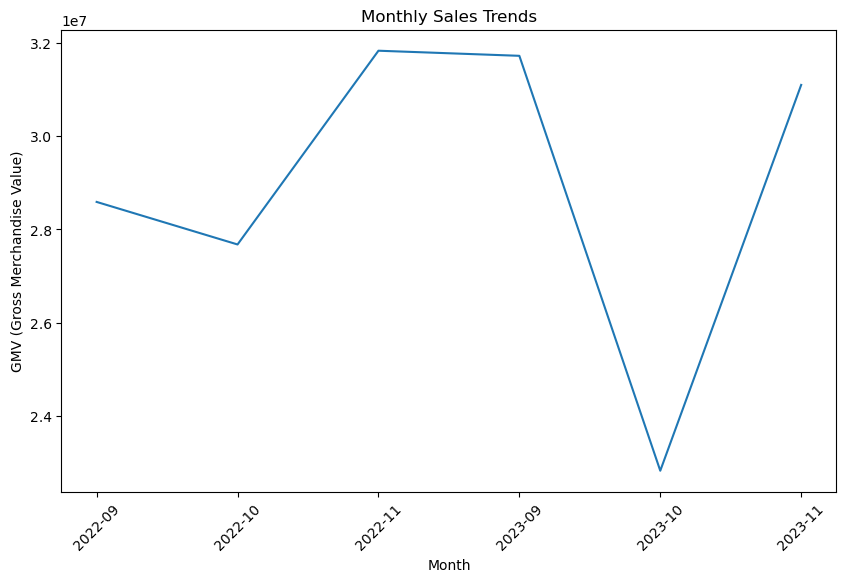

In [18]:
# Monthly Sales Trends
monthly_sales = df.groupby('month')['placed_gmv'].sum().reset_index()

# Convert 'month' to string for plotting
monthly_sales['month'] = monthly_sales['month'].astype(str)

# Plot Monthly Sales Trends
plt.figure(figsize=(10, 6))
sns.lineplot(x='month', y='placed_gmv', data=monthly_sales)
plt.title("Monthly Sales Trends")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("GMV (Gross Merchandise Value)")
plt.show()

C:\Users\srini\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\srini\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


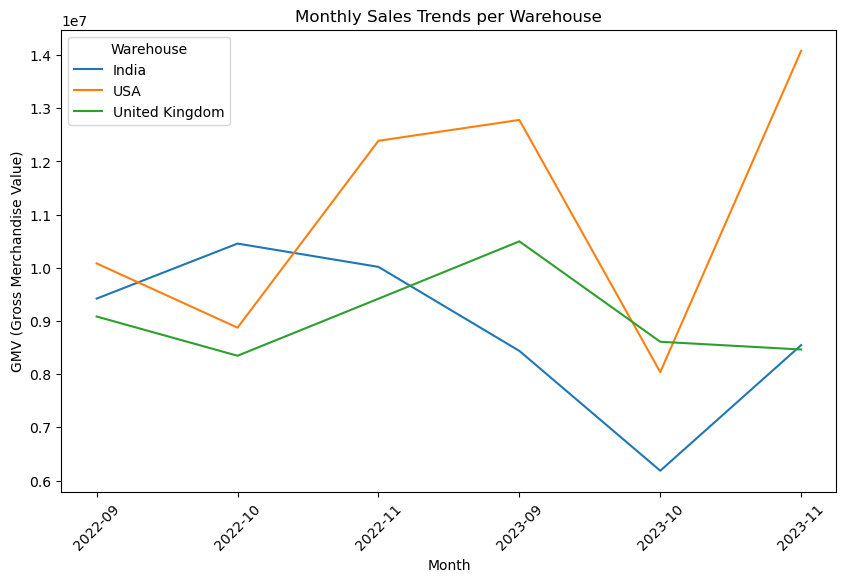

In [20]:
# Monthly Sales Trends per Warehouse
monthly_sales_per_warehouse = df.groupby(['warehouse_name', 'month'])['placed_gmv'].sum().reset_index()

# Convert 'month' to string for plotting
monthly_sales_per_warehouse['month'] = monthly_sales_per_warehouse['month'].astype(str)

# Plot Monthly Sales Trends per Warehouse
plt.figure(figsize=(10, 6))
sns.lineplot(x='month', y='placed_gmv', hue='warehouse_name', data=monthly_sales_per_warehouse)
plt.title("Monthly Sales Trends per Warehouse")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("GMV (Gross Merchandise Value)")
plt.legend(title="Warehouse")
plt.show()

In [16]:
# Warehouse Performance (GMV and Order Count)
warehouse_performance = df.groupby('warehouse_name').agg(total_gmv=('placed_gmv', 'sum'),
                                                       order_count=('order_id', 'nunique')).reset_index()
print("Warehouse Performance:\n", warehouse_performance)

Warehouse Performance:
    warehouse_name    total_gmv  order_count
0           India  53066153.46         6080
1             USA  66248696.45         8215
2  United Kingdom  54423087.40         6844


In [17]:
# Repeat Customers Analysis
repeat_customers = df.groupby('user_id')['order_id'].nunique()
repeat_customers = repeat_customers[repeat_customers > 1].count()
print(f"Total Repeat Customers: {repeat_customers}")

Total Repeat Customers: 2729
